# Lab 4: Improving and Comparing Machine Learning Models

**Name:** Abdul Moiz Soomro  
**Roll Number:** 023-24-0291  
**GitHub Repository:** https://github.com/abdulmoizsoomrocs/ML_Lab_4  
**Section:** H

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,f1_score,recall_score,confusion_matrix,ConfusionMatrixDisplay)

In [2]:

df = pd.read_csv("clean_churn.csv")



In [3]:
# Task 1

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


In [4]:
X=df.drop(columns=["Churn"])
y=df["Churn"]

In [5]:
X=pd.get_dummies(X,drop_first=True)

In [6]:
# Task 2


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_depth = 5

dt_model = DecisionTreeClassifier(
    max_depth=best_depth, random_state=42
)

dt_model.fit(X_train, y_train)



,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in

In [7]:
dt_predict=dt_model.predict(X_test)

In [8]:
dt_accuracy=accuracy_score(y_test,dt_predict)
dt_precision=precision_score(y_test,dt_predict,zero_division=0)
dt_f1_score=f1_score(y_test,dt_predict,zero_division=0)
dt_recall=recall_score(y_test,dt_predict,zero_division=0)

print("Decision Tree Baseline")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", recall_score)
print("F1-score :", dt_f1_score)



Decision Tree Baseline
Accuracy : 0.7782515991471215
Precision: 0.5807291666666666
Recall   : <function recall_score at 0x00000147D0B765C0>
F1-score : 0.5883905013192612


In [9]:
#TASK3
rf_model=RandomForestClassifier(n_estimators=200,random_state=0)
rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)

# Task 4

A Random Forest is a collection of many Decision Trees rather than a single Decision Tree. Each tree is trained using different samples of the data and a random selection of features. This makes Random Forest better at generalizing because a single Decision Tree can easily overfit the training data. By combining the predictions of many trees, Random Forest usually provides more stable and accurate results.


In [10]:
#Task5
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

print("Random Forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)

Random Forest
Accuracy : 0.7882018479033405
Precision: 0.62751677852349
Recall   : 0.5
F1-score : 0.5565476190476191


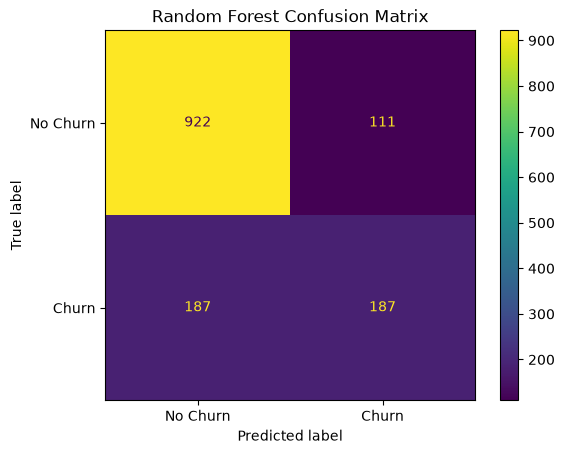

In [11]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [12]:
#task6
comparison=pd.DataFrame({
    "Model":["Decision Tree","Random Forest"],
    "Accuracy":[dt_accuracy,rf_accuracy],
    "Precision": [dt_precision,rf_precision],
    "Recall": [dt_recall,rf_recall],
    "F1-score": [dt_f1_score,rf_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.778252,0.580729,0.596257,0.588391
1,Random Forest,0.788202,0.627517,0.500000,0.556548


# Task 7

Random Forest performs slightly better in accuracy and precision, while the Decision Tree performs better in recall and F1-score. However, the differences between the two models are small.

Since the dataset is imbalanced, accuracy is not the most reliable metric to use alone. Recall and F1-score are more important because they give a better idea of how well the model identifies the minority class.

Based on recall and F1-score, the Decision Tree is the preferable model.


In [13]:
#task8
from sklearn.model_selection import cross_val_score
dt_cv_score=cross_val_score(dt_model,X,y,cv=5,scoring="f1")
print("Decision Trees f1 score")
print(dt_cv_score)
print("Mean", dt_cv_score.mean())
print("Standard Deviation", dt_cv_score.std())

Decision Trees f1 score
[0.56842105 0.47619048 0.47868852 0.51986755 0.56894049]
Mean 0.5224216193099778
Standard Deviation 0.040832288592612585


In [14]:
rf_cv_score=cross_val_score(rf_model,X,y,cv=5,scoring="f1")
print("Random Forest f1 score")
print(rf_cv_score)
print("Mean", rf_cv_score.mean())
print("Standard Deviation", rf_cv_score.std())

Random Forest f1 score
[0.55130168 0.55606759 0.52212389 0.56112853 0.56193353]
Mean 0.5505110456105716
Standard Deviation 0.014700577036176965


In [15]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Mean F1": [
        dt_cv_score.mean(),
        rf_cv_score.mean()
    ],
    "Std F1": [
        dt_cv_score.std(),
        rf_cv_score.std()
    ]
})

cv_comparison

,Model,Mean F1,Std F1
0,Decision Tree,0.522422,0.040832
1,Random Forest,0.550511,0.014701


# Task 9

The 5-fold cross-validation results give a more reliable estimate of model performance because each model is tested on five different validation folds. The mean F1-score shows the average performance, while the standard deviation shows how much the performance changes between the folds.

If Random Forest has a higher mean F1-score, it provides stronger evidence that it generalizes better than the Decision Tree. Cross-validation makes the comparison more reliable because it does not depend on only one train/test split.


In [16]:
#task10
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
para_grid={
    "n_estimators":[100,200],
    "max_depth":[5,10],
    "min_samples_split":[2,5]
}

In [17]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=0),
    param_grid=para_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbos

In [18]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross-Validation F1:
0.5732170529208956


In [19]:
tuned_rf = grid_search.best_estimator_

# Task 11

GridSearchCV tested different combinations of Random Forest hyperparameters using 5-fold cross-validation. The best parameters were selected based on the F1-score instead of accuracy because churn is the minority class.

The selected parameters represent the combination that gave the best F1-score among all the combinations tested.



In [20]:
#task12
tuned_pred = tuned_rf.predict(X_test)
tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(
    y_test,
    tuned_pred,
    zero_division=0
)
tuned_recall = recall_score(
    y_test,
    tuned_pred,
    zero_division=0
)
tuned_f1 = f1_score(
    y_test,
    tuned_pred,
    zero_division=0
)

print("Tuned Random Forest")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1-score :", tuned_f1)

Tuned Random Forest
Accuracy : 0.7967306325515281
Precision: 0.6496598639455783
Recall   : 0.5106951871657754
F1-score : 0.5718562874251497


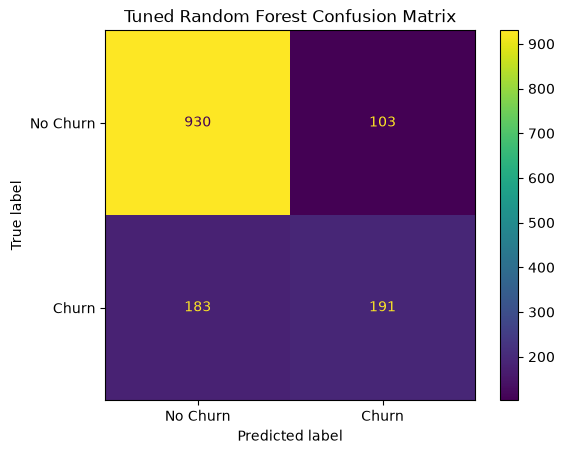

In [21]:
cm_tuned = confusion_matrix(y_test, tuned_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

In [22]:
#task13
final_comparison=pd.DataFrame({
    "models":["Decision Tree","Default Random Forest","Tuned Random Forest"],
    "Accuracy":[dt_accuracy,rf_accuracy,tuned_accuracy],
     "Precision": [dt_precision,rf_precision,tuned_precision],
    "Recall": [dt_recall,rf_recall,tuned_recall],
    "F1-score": [dt_f1_score,rf_f1,tuned_f1]
})
final_comparison

,models,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.778252,0.580729,0.596257,0.588391
1,Default Random Forest,0.788202,0.627517,0.500000,0.556548
2,Tuned Random Forest,0.796731,0.649660,0.510695,0.571856


In [23]:
#task13
best_model = final_comparison.loc[
    final_comparison["F1-score"].idxmax()
]

print("Best model based on F1-score:")
print(best_model)

Best model based on F1-score:
models       Decision Tree
Accuracy          0.778252
Precision         0.580729
Recall            0.596257
F1-score          0.588391
Name: 0, dtype: object




The final comparison includes the original Decision Tree, the default Random Forest, and the tuned Random Forest. The models are compared using accuracy, precision, recall, and F1-score instead of relying only on accuracy.

The model with the highest F1-score provides a better balance between identifying churn customers and avoiding incorrect predictions. Therefore, the final model should be selected by considering the F1-score, recall, precision, and cross-validation results together.


In [24]:
#task14
importances = tuned_rf.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

tenure                            0.191824
TotalCharges                      0.169704
MonthlyCharges                    0.117319
InternetService_Fiber optic       0.085640
Contract_Two year                 0.058149
PaymentMethod_Electronic check    0.052918
Contract_One year                 0.033643
OnlineSecurity_Yes                0.032649
TechSupport_Yes                   0.022805
PaperlessBilling_Yes              0.017227
dtype: float64

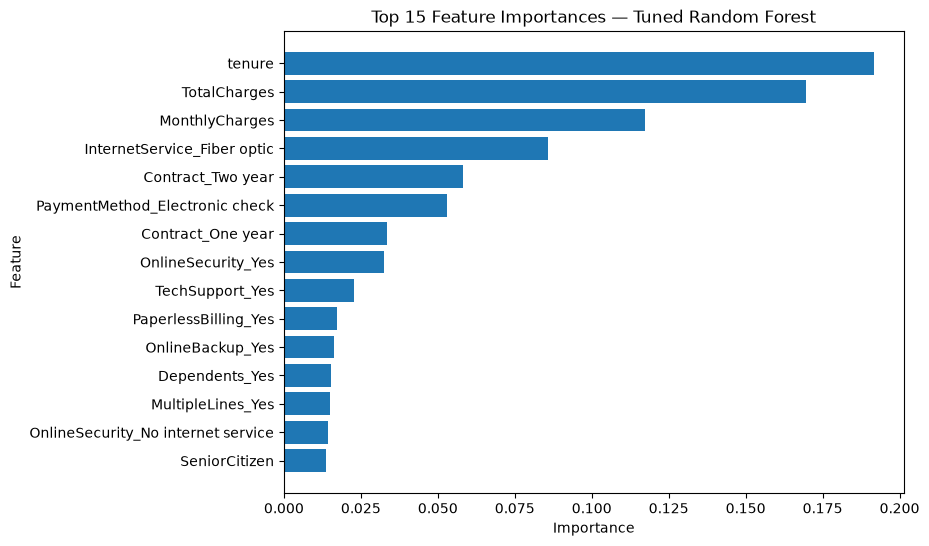

In [25]:
#task15
top_features = feature_importance.head(15).sort_values()

plt.figure(figsize=(8, 6))

plt.barh(
    top_features.index,
    top_features.values
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Tuned Random Forest")

plt.show()

In [26]:
print("Top 5 Important Features:")
print(feature_importance.head(5))

Top 5 Important Features:
tenure                         0.191824
TotalCharges                   0.169704
MonthlyCharges                 0.117319
InternetService_Fiber optic    0.085640
Contract_Two year              0.058149
dtype: float64


The feature importance plot shows which features were most useful for the Random Forest's predictions. The top features indicate which customer characteristics may have a stronger relationship with churn.

Features such as tenure, contract type, monthly charges, and total charges may be important because customer commitment and billing behavior can affect churn. These results can also be compared with the EDA from Lab 2 and the Decision Tree results from Lab 3 to see if similar patterns were found.


In [27]:
final_comparison.sort_values(
    by="F1-score",
    ascending=False
)

,models,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.778252,0.580729,0.596257,0.588391
2,Tuned Random Forest,0.796731,0.649660,0.510695,0.571856
1,Default Random Forest,0.788202,0.627517,0.500000,0.556548


In [28]:
print("Decision Tree CV F1:",
      dt_cv_score.mean())

print("Random Forest CV F1:",
      rf_cv_score.mean())

print("Tuned Random Forest CV F1:",
      grid_search.best_score_)

Decision Tree CV F1: 0.5224216193099778
Random Forest CV F1: 0.5505110456105716
Tuned Random Forest CV F1: 0.5732170529208956


Based on the test-set metrics and cross-validation results, the Tuned Random Forest is selected as the final model because it provides a good balance between precision, recall, and F1-score.

Unlike a single Decision Tree, Random Forest combines multiple trees, which can help the model generalize better. Hyperparameter tuning further improves the model by finding a configuration that performs well during cross-validation.

Therefore, the Tuned Random Forest is selected as the final model based on both test-set performance and cross-validation results.


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [32]:
#task16
submission_df = pd.read_csv("customer_churn.csv")

submission_df["TotalCharges"] = pd.to_numeric(
    submission_df["TotalCharges"],
    errors="coerce"
)

submission_df = submission_df.dropna()

customer_ids = submission_df["customerID"]

In [33]:
submission_features = submission_df.drop(
    columns=["customerID", "Churn"]
)

submission_features = pd.get_dummies(
    submission_features,
    drop_first=True
)

In [34]:
submission_features = submission_features.reindex(
    columns=X.columns,
    fill_value=0
)

In [35]:
submission_predictions = tuned_rf.predict(
    submission_features
)

In [36]:
submission_predictions = np.where(
    submission_predictions == 1,
    "Yes",
    "No"
)

In [37]:
submission = pd.DataFrame({
    "customerID": customer_ids.values,
    "Churn": submission_predictions
})

submission.head()

,customerID,Churn
0,7590-VHVEG,Yes
1,5575-GNVDE,No
2,3668-QPYBK,Yes
3,7795-CFOCW,No
4,9237-HQITU,Yes


In [38]:
submission.to_csv(
    "submission.csv",
    index=False
)

In [39]:
print("Submission shape:", submission.shape)

print("\nColumns:")
print(submission.columns)

print("\nChurn predictions:")
print(submission["Churn"].value_counts())

Submission shape: (7032, 2)

Columns:
Index(['customerID', 'Churn'], dtype='str')

Churn predictions:
Churn
No     5569
Yes    1463
Name: count, dtype: int64


# Task 17

In this lab, I compared a Decision Tree, a default Random Forest, and a tuned Random Forest for predicting customer churn. Random Forest provides a stronger approach by combining multiple Decision Trees, which can reduce the limitations of using a single tree.

I used accuracy, precision, recall, F1-score, confusion matrices, and 5-fold cross-validation to compare the models. I also used GridSearchCV to tune the Random Forest and find better parameters based on F1-score.

The final model was selected using both test-set performance and cross-validation results rather than relying only on training performance. However, the model still has some limitations, such as class imbalance. Its performance could be improved further through better feature engineering and by trying other machine learning algorithms.


# Task 18

If I had more time, I would try other algorithms such as Logistic Regression, Gradient Boosting, and XGBoost and compare their performance with Random Forest. I would also try techniques such as class weights or resampling to handle the class imbalance.

I would perform more extensive hyperparameter tuning to improve the model further. Finally, I would work on better feature engineering and check whether the most important features remain consistent across different models.
